# Visualización

In [87]:
# Primero cargamos y revisamos la base de datos

# Importa pandas para trabajar con la base de datos.
import pandas as pd

# Importa Plotly Express para crear gráficos interactivos.
import plotly.express as px

# Lee la copia de la base del Assignment 2 que guardamos dentro de assignment_3/datos.
datos = pd.read_csv("datos/dataset.csv")

# Muestra las primeras cinco filas para comprobar que la base se cargó correctamente.
datos.head()

,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,1,Amazonas,Chachapoyas,-6.23169,-77.86903,455.0,0,4,2
1,2,Áncash,Huaraz,-9.52614,-77.52869,1058.3,3,5,5
2,3,Apurímac,Abancay,-13.63426,-72.88380,670.6,2,7,4
3,4,Arequipa,Arequipa,-16.39899,-71.53747,235.3,1,7,6
4,5,Ayacucho,Ayacucho,-13.16380,-74.22345,467.5,1,7,5


In [88]:
# Muestra el número de filas y columnas de la base.
print("Dimensiones:", datos.shape)

# Muestra los nombres de las columnas disponibles.
print("Columnas:", datos.columns.tolist())

# Comprueba si existen valores ausentes en las variables que utilizaremos.
print(datos[["departamento", "capital", "lluvia_total_mm"]].isna().sum())

Dimensiones: (25, 9)
Columnas: ['ubigeo', 'departamento', 'capital', 'latitud', 'longitud', 'lluvia_total_mm', 'dias_lluvia_fuerte', 'declaratorias', 'prorrogas']
departamento       0
capital            0
lluvia_total_mm    0
dtype: int64


In [89]:

#2. Ordenar de mayor a menor según la precipitación acumulada

# Ordena los departamentos de mayor a menor según la precipitación acumulada.
lluvia_ordenada = datos.sort_values(
    "lluvia_total_mm",
    ascending=False
)

# Muestra las columnas relevantes para comprobar manualmente el ranking.
lluvia_ordenada[
    ["departamento", "capital", "lluvia_total_mm"]
]

,departamento,capital,lluvia_total_mm
15,Loreto,Iquitos,1361.8
11,Junín,Huancayo,1276.9
16,Madre de Dios,Puerto Maldonado,1149.5
1,Áncash,Huaraz,1058.3
24,Ucayali,Pucallpa,887.4
18,Pasco,Cerro de Pasco,839.3
8,Huancavelica,Huancavelica,819.2
20,Puno,Puno,728.6
21,San Martín,Moyobamba,681.7
5,Cajamarca,Cajamarca,671.2


## Gráfico de barras

In [103]:
# Crea una copia ordenada de mayor a menor precipitación acumulada.
lluvia_ordenada = datos.sort_values(
    "lluvia_total_mm",
    ascending=False
).copy()

# Crea el gráfico de barras horizontales.
fig_barras = px.bar(

    # Usa la tabla ordenada.
    lluvia_ordenada,

    # La longitud de la barra representa la precipitación acumulada.
    x="lluvia_total_mm",

    # Cada barra representa un departamento.
    y="departamento",

    # Define la orientación horizontal.
    orientation="h",

    # Muestra información adicional al pasar el mouse.
    hover_data={
        "capital": True,
        "lluvia_total_mm": ":.1f"
    },

    # Define nombres comprensibles para el tooltip.
    labels={
        "departamento": "Departamento",
        "capital": "Capital",
        "lluvia_total_mm": "Precipitación acumulada (mm)"
    }
)

# Ordena las barras para que el mayor valor aparezca arriba.
fig_barras.update_yaxes(
    categoryorder="total ascending"
)

# Define el color azul oscuro de las barras.
fig_barras.update_traces(
    marker_color="#0B6FA4"
)

# Ajusta el estilo general del gráfico.
fig_barras.update_layout(

    # Usa un fondo azul muy claro inspirado en el ejemplo del Economist.
    plot_bgcolor="#E8F1F5",

    # Usa el mismo fondo alrededor del gráfico.
    paper_bgcolor="#E8F1F5",

    # Define una tipografía sencilla y oscura.
    font=dict(
        family="Arial",
        size=12,
        color="#1F1F1F"
    ),

    # Da suficiente espacio horizontal al gráfico.
    width=900,

    # Da espacio vertical suficiente para las 25 barras.
    height=720,

    # Reserva espacio para título, subtítulo y fuente.
    margin=dict(
        l=150,
        r=40,
        t=130,
        b=90
    ),

    # Elimina la leyenda porque solo tenemos una serie.
    showlegend=False,

    # Coloca el eje X en la parte superior.
    xaxis=dict(
        side="top"
    )
)

# Configura el eje de precipitación.
fig_barras.update_xaxes(

    # Coloca el eje en la parte superior.
    side="top",

    # Muestra líneas verticales de referencia.
    showgrid=True,

    # Usa líneas suaves para no competir con las barras.
    gridcolor="#C9D7DF",

    # Elimina la línea del cero.
    zeroline=False,

    # Elimina el borde exterior.
    showline=False,

    # Elimina el título tradicional del eje.
    title=None
)

# Configura el eje de departamentos.
fig_barras.update_yaxes(

    # Elimina líneas horizontales.
    showgrid=False,

    # Elimina el título "Departamento".
    title=None,

    # Elimina marcas innecesarias.
    ticks=""
)

# Agrega el título principal arriba a la izquierda.
fig_barras.add_annotation(

    # Ubica el texto usando coordenadas relativas al gráfico completo.
    x=0,
    y=1.16,

    # Define el título principal.
    text="<b>Precipitación acumulada en las capitales departamentales</b>",

    # Usa coordenadas del área completa del gráfico.
    xref="paper",
    yref="paper",

    # Alinea el texto a la izquierda.
    xanchor="left",

    # No dibuja una flecha.
    showarrow=False,

    # Define el tamaño del título.
    font=dict(
        size=20,
        color="#1F1F1F"
    )
)

# Agrega el subtítulo con periodo y unidad de medida.
fig_barras.add_annotation(

    # Ubica el subtítulo debajo del título.
    x=0,
    y=1.105,

    # Explica el periodo y la unidad.
    text="Periodo: 1 de enero al 31 de mayo de 2024, mm",

    # Usa coordenadas relativas al gráfico.
    xref="paper",
    yref="paper",

    # Alinea a la izquierda.
    xanchor="left",

    # No dibuja flecha.
    showarrow=False,

    # Usa un tamaño menor que el título.
    font=dict(
        size=13,
        color="#404040"
    )
)



# Agrega la fuente al pie del gráfico.
fig_barras.add_annotation(

    # Coloca la fuente debajo del gráfico.
    x=0,
    y=-0.11,

    # Especifica la fuente de los datos.
    text="Fuente: Open-Meteo. Elaboración propia.",

    # Usa coordenadas relativas al gráfico.
    xref="paper",
    yref="paper",

    # Alinea la fuente a la izquierda.
    xanchor="left",

    # No dibuja flecha.
    showarrow=False,

    # Usa un tamaño discreto.
    font=dict(
        size=11,
        color="#666666"
    )
)

# Muestra el gráfico.
fig_barras.show()

### ¿En qué capitales departamentales se registró mayor precipitación acumulada entre enero y mayo de 2024?

La precipitación acumulada entre el 1 de enero y el 31 de mayo de 2024 fue más alta en la capital de Loreto, seguida por las capitales de Junín y Madre de Dios. En cambio, Callao, Ica y Lima registraron los menores acumulados de precipitación dentro del conjunto analizado.
Los valores corresponden al punto meteorológico asociado a la capital de cada departamento, por lo que no representan necesariamente el promedio de precipitación de todo el territorio departamental.

## Gráfico de dispersión

In [91]:
# Crea una copia con todas las variables necesarias para el scatterplot.
scatter_datos = datos[
    [
        "departamento",
        "capital",
        "lluvia_total_mm",
        "declaratorias",
        "prorrogas"
    ]
].copy()

In [92]:
# Crea una nueva columna sumando declaratorias y prórrogas.
scatter_datos["total_normas_emergencia"] = (
    scatter_datos["declaratorias"]
    + scatter_datos["prorrogas"]
)

In [93]:
# Comprueba que la nueva columna se haya creado correctamente.
scatter_datos[
    [
        "departamento",
        "declaratorias",
        "prorrogas",
        "total_normas_emergencia"
    ]
].head()

,departamento,declaratorias,prorrogas,total_normas_emergencia
0,Amazonas,4,2,6
1,Áncash,5,5,10
2,Apurímac,7,4,11
3,Arequipa,7,6,13
4,Ayacucho,7,5,12


In [94]:
y=scatter_datos["total_normas_emergencia"]

In [95]:
# Suma todas las declaratorias registradas en la base.
total_declaratorias = scatter_datos["declaratorias"].sum()

# Suma todas las prórrogas registradas en la base.
total_prorrogas = scatter_datos["prorrogas"].sum()

# Muestra ambos totales para verificar.
print("Total de declaratorias:", total_declaratorias)
print("Total de prórrogas:", total_prorrogas)

Total de declaratorias: 99
Total de prórrogas: 68


In [96]:
# Importa pandas para trabajar con la base de datos.
import pandas as pd

# Importa Plotly Graph Objects para construir el gráfico con mayor control visual.
import plotly.graph_objects as go

In [97]:
# Lee la base de datos utilizada en el Assignment 3.
datos = pd.read_csv("datos/dataset.csv")

# Crea una copia con las variables necesarias para este gráfico.
scatter_datos = datos[
    [
        "departamento",
        "capital",
        "lluvia_total_mm",
        "declaratorias",
        "prorrogas"
    ]
].copy()

# Suma las declaratorias y sus prórrogas para obtener
# el total de normas de emergencia contabilizadas por departamento.
scatter_datos["total_normas_emergencia"] = (
    scatter_datos["declaratorias"]
    + scatter_datos["prorrogas"]
)

# Cuenta cuántas unidades territoriales participan en el análisis.
n_departamentos = len(scatter_datos)

# Muestra las primeras filas para verificar la nueva tabla.
scatter_datos.head()

,departamento,capital,lluvia_total_mm,declaratorias,prorrogas,total_normas_emergencia
0,Amazonas,Chachapoyas,455.0,4,2,6
1,Áncash,Huaraz,1058.3,5,5,10
2,Apurímac,Abancay,670.6,7,4,11
3,Arequipa,Arequipa,235.3,7,6,13
4,Ayacucho,Ayacucho,467.5,7,5,12


In [98]:
# Comprueba que no existan valores ausentes en las variables del gráfico.
print(
    scatter_datos[
        [
            "departamento",
            "lluvia_total_mm",
            "total_normas_emergencia"
        ]
    ].isna().sum()
)

# Muestra el número total de unidades territoriales.
print("Total de unidades territoriales:", n_departamentos)

departamento               0
lluvia_total_mm            0
total_normas_emergencia    0
dtype: int64
Total de unidades territoriales: 25


In [99]:
# Define manualmente dónde aparecerá el nombre de cada departamento.
posiciones_personalizadas = {
    "Amazonas": "top left",
    "Áncash": "top left",
    "Apurímac": "top right",
    "Arequipa": "middle right",
    "Ayacucho": "top left",
    "Cajamarca": "bottom left",
    "Callao": "bottom right",
    "Cusco": "bottom right",
    "Huancavelica": "top right",
    "Huánuco": "top left",
    "Ica": "middle left",
    "Junín": "top left",
    "La Libertad": "top right",
    "Lambayeque": "middle right",  # <- cambio importante
    "Lima": "middle right",
    "Loreto": "top right",
    "Madre de Dios": "bottom left",
    "Moquegua": "bottom center",
    "Pasco": "bottom right",
    "Piura": "top center",
    "Puno": "top center",
    "San Martín": "bottom center",
    "Tacna": "middle right",
    "Tumbes": "top center",
    "Ucayali": "top right"
}

# Construye una lista de posiciones siguiendo exactamente
# el orden de los departamentos en scatter_datos.
# Si algún departamento no estuviera en el diccionario,
# Plotly utilizará "top center" como posición segura.
posiciones_texto = [
    posiciones_personalizadas.get(departamento, "top center")
    for departamento in scatter_datos["departamento"]
]

# Comprueba las posiciones generadas.
print(posiciones_texto)



['top left', 'top left', 'top right', 'middle right', 'top left', 'bottom left', 'bottom right', 'bottom right', 'top right', 'top left', 'middle left', 'top left', 'top right', 'middle right', 'middle right', 'top right', 'bottom left', 'bottom center', 'bottom right', 'top center', 'top center', 'bottom center', 'middle right', 'top center', 'top right']


In [100]:
# Crea una figura vacía.
fig_scatter = go.Figure()

# Agrega los puntos y los nombres de los departamentos.
fig_scatter.add_trace(
    go.Scatter(

        # Eje X: precipitación acumulada durante la temporada.
        x=scatter_datos["lluvia_total_mm"],

        # Eje Y: declaratorias más prórrogas contabilizadas por departamento.
        y=scatter_datos["total_normas_emergencia"],

        # Usa el nombre del departamento como etiqueta visible.
        text=scatter_datos["departamento"],

        # Muestra simultáneamente los puntos y sus nombres.
        mode="markers+text",

        # Usa las posiciones definidas anteriormente.
        textposition=posiciones_texto,

        # Guarda información adicional para mostrarla en el hover.
        customdata=scatter_datos[
            [
                "capital",
                "declaratorias",
                "prorrogas"
            ]
        ],

        # Define lo que aparece al pasar el mouse sobre un punto.
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Capital: %{customdata[0]}<br>"
            "Precipitación acumulada: %{x:.1f} mm<br>"
            "Declaratorias: %{customdata[1]}<br>"
            "Prórrogas: %{customdata[2]}<br>"
            "Total de normas: %{y}"
            "<extra></extra>"
        ),

        # Define el aspecto de los puntos.
        marker=dict(

            # Tamaño de cada punto.
            size=11,

            # Azul oscuro inspirado en el estilo editorial usado anteriormente.
            color="#0B5A7D",

            # Hace los puntos ligeramente transparentes.
            opacity=0.72,

            # Agrega un borde discreto.
            line=dict(
                width=0.8,
                color="#083D56"
            )
        ),

        # Define el aspecto de los nombres de los departamentos.
        textfont=dict(
            size=10,
            color="#1F1F1F"
        ),

        # Evita una leyenda innecesaria.
        name=""
    )
)

# Ajusta el diseño general de la figura.
fig_scatter.update_layout(

    # Usa un fondo azul muy claro.
    plot_bgcolor="#DCE8EE",

    # Mantiene el mismo fondo en toda la figura.
    paper_bgcolor="#DCE8EE",

    # Define una tipografía sencilla y legible.
    font=dict(
        family="Arial",
        size=12,
        color="#1F1F1F"
    ),

    # Define un ancho suficiente para las etiquetas.
    width=980,

    # Define una altura amplia.
    height=850,

    # Reserva bastante espacio arriba para el subtítulo
    # y abajo para el eje X y la fuente.
    margin=dict(
        l=100,
        r=60,
        t=270,
        b=190
    ),

    # Elimina la leyenda.
    showlegend=False,

    # El título se agregará manualmente.
    title=""
)

# Configura el eje de precipitación acumulada.
fig_scatter.update_xaxes(

    # Nombra claramente la variable.
    title="Precipitación acumulada (mm)",

    # No muestra cuadrículas verticales.
    showgrid=False,

    # Mantiene visible la línea inferior del eje.
    showline=True,

    # Define su color.
    linecolor="#1F1F1F",

    # Define su grosor.
    linewidth=1.5,

    # Coloca las marcas hacia afuera.
    ticks="outside",

    # Define el color de las marcas.
    tickcolor="#1F1F1F",

    # Elimina una línea especial en cero.
    zeroline=False,

    # Separa el título del eje de los números.
    title_standoff=25
)

# Configura el eje de normas de emergencia.
fig_scatter.update_yaxes(

    # Explica exactamente qué está contando.
    title="Declaratorias y prórrogas",

    # Mantiene líneas horizontales de referencia.
    showgrid=True,

    # Usa líneas blancas suaves.
    gridcolor="white",

    # Define el grosor de las líneas horizontales.
    gridwidth=2,

    # Mantiene la línea del eje.
    showline=True,

    # Define su color.
    linecolor="#1F1F1F",

    # Define su grosor.
    linewidth=1.5,

    # Coloca marcas hacia afuera.
    ticks="outside",

    # Define el color de las marcas.
    tickcolor="#1F1F1F",

    # Elimina la línea especial en cero.
    zeroline=False,

    # Separa el título del eje.
    title_standoff=15
)

# Agrega el título principal.
fig_scatter.add_annotation(

    # Coloca el título hacia la izquierda.
    x=0,
    y=1.33,

    # Usa coordenadas relativas al gráfico.
    xref="paper",
    yref="paper",

    # Define el texto.
    text="<b>¿Más lluvia, más declaratorias y prórrogas?</b>",

    # No dibuja una flecha.
    showarrow=False,

    # Alinea a la izquierda.
    xanchor="left",
    align="left",

    # Define el estilo.
    font=dict(
        size=22,
        color="#1F1F1F"
    )
)

# Agrega el subtítulo explicativo debajo del título principal.
fig_scatter.add_annotation(

    # Coloca el subtítulo hacia la izquierda.
    x=0,
    y=1.23,

    # Usa coordenadas relativas al área del gráfico.
    xref="paper",
    yref="paper",

    # Alinea el bloque a la izquierda.
    xanchor="left",
    align="left",

    # No dibuja flecha.
    showarrow=False,

    # Escribe el texto del subtítulo con el detalle metodológico necesario.
    text=(
        "Cada punto representa una unidad territorial.<br>"
        "Periodo del acumulado de lluvias: 1 de enero al 31 de mayo de 2024.<br>"
        f"Normas de emergencia: {total_declaratorias} declaratorias y "
        f"{total_prorrogas} prórrogas contabilizadas por departamento "
        "entre el 1 de enero y el 31 de mayo de 2024.<br>"
        f"Universo analizado: {n_departamentos} unidades territoriales "
        "(24 departamentos y la Provincia Constitucional del Callao)."
    ),

    # Define el estilo visual del subtítulo.
    font=dict(
        size=13,
        color="#303030"
    )
)

# Agrega la fuente debajo del eje X, dejando suficiente separación.
fig_scatter.add_annotation(

    # Alinea la fuente con el borde izquierdo del gráfico.
    x=0,
    y=-0.30,

    # Usa coordenadas relativas al gráfico.
    xref="paper",
    yref="paper",

    # Especifica las fuentes utilizadas.
    text=(
        "Fuente: Open-Meteo y decretos de emergencia de la Presidencia "
        "del Consejo de Ministros. Elaboración propia."
    ),

    # No dibuja flecha.
    showarrow=False,

    # Alinea el texto a la izquierda.
    xanchor="left",

    # Usa un tamaño discreto.
    font=dict(
        size=11,
        color="#666666"
    )
)

# Muestra el scatterplot terminado.
fig_scatter.show()

### ¿Los departamentos con mayor precipitación acumulada tienden a tener más declaratorias de emergencia?

Interpretación. No se observa una correspondencia directa entre mayor precipitación acumulada y un mayor número de declaratorias y prórrogas de emergencia. Departamentos como Loreto, Junín y Madre de Dios, cuyas capitales presentan algunos de los mayores acumulados de precipitación del periodo, no se ubican entre los territorios con mayor número de normas de emergencia. En cambio, Lima presenta un número relativamente alto de declaratorias y prórrogas pese a registrar un acumulado de precipitación bajo en el punto de medición utilizado. Esto sugiere que la emisión de normas de emergencia no depende únicamente del volumen acumulado de lluvia y puede estar asociada también a otros factores territoriales, de vulnerabilidad o de afectación.

Limitación. La precipitación fue medida en un único punto por unidad territorial: la capital departamental. Por tanto, el valor utilizado no representa necesariamente las condiciones de lluvia de todo el departamento. Esta limitación es especialmente relevante en territorios extensos o con alta heterogeneidad climática, donde pueden existir grandes diferencias entre provincias y distritos. En consecuencia, el gráfico permite una comparación exploratoria, pero no es suficiente para evaluar con precisión si las declaratorias de emergencia coincidieron con las zonas donde efectivamente se registraron las mayores precipitaciones.

Limitación temporal. La variable de precipitación corresponde al acumulado entre el 1 de enero y el 31 de mayo de 2024, mientras que las declaratorias y prórrogas se emitieron en distintos momentos dentro de ese periodo. Por ello, el gráfico no establece que la precipitación acumulada observada haya precedido o causado cada declaratoria.


## Boxplot

In [101]:
# Importa Plotly Express, que usaremos para construir el boxplot.
import plotly.express as px


# Crea el boxplot usando la columna de precipitación acumulada.
fig_box = px.box(
    
    # Usa el dataframe principal.
    datos,
    
    # Define la variable numérica que irá en el eje X.
    x="lluvia_total_mm",
    
    # Muestra también todos los puntos individuales junto con la caja.
    points="all",
    
    # Cuando se pase el mouse sobre un punto, se mostrará el departamento.
    hover_name="departamento",
    
    # Cambia el nombre que aparecerá en el eje X.
    labels={
        "lluvia_total_mm": "Precipitación acumulada (mm)"
    }
)


# Ajusta el estilo visual de la caja y de los puntos.
fig_box.update_traces(
    
    # Hace la caja más delgada para que no se vea tan grande.
    width=0.18,
    
    # Define el color de relleno de la caja con algo de transparencia.
    fillcolor="rgba(11, 90, 125, 0.28)",
    
    # Define el color y grosor del borde de la caja.
    line=dict(
        color="#0B5A7D",
        width=2
    ),
    
    # Ajusta el aspecto de los puntos individuales.
    marker=dict(
        color="#0B5A7D",
        size=8,
        opacity=0.75
    )
)


# Ajusta el diseño general del gráfico.
fig_box.update_layout(
    
    # Define el color de fondo del área del gráfico.
    plot_bgcolor="#DCE8EE",
    
    # Define el color de fondo de toda la figura.
    paper_bgcolor="#DCE8EE",
    
    # Define el ancho total de la figura.
    width=1100,
    
    # Define la altura total de la figura.
    height=620,
    
    # Define los márgenes: izquierda, derecha, arriba y abajo.
    margin=dict(
        l=60,
        r=40,
        t=190,
        b=130
    ),
    
    # Define la fuente general del gráfico.
    font=dict(
        family="Arial",
        size=12,
        color="#1F1F1F"
    ),
    
    # Oculta la leyenda porque aquí no la necesitamos.
    showlegend=False
)


# Ajusta el eje X.
fig_box.update_xaxes(
    
    # Coloca el título del eje X.
    title="Precipitación acumulada (mm)",
    
    # Muestra líneas de cuadrícula verticales.
    showgrid=True,
    
    # Define el color de las líneas de cuadrícula.
    gridcolor="white",
    
    # Oculta la línea especial del cero.
    zeroline=False,
    
    # Da un poco más de espacio entre el eje y su título.
    title_standoff=22
)


# Ajusta el eje Y.
fig_box.update_yaxes(
    
    # Oculta las etiquetas del eje Y, porque no aportan información aquí.
    showticklabels=False,
    
    # Oculta la cuadrícula horizontal.
    showgrid=False,
    
    # Quita el título del eje Y.
    title=None,
    
    # Define en qué parte vertical de la figura aparecerá el gráfico.
    # Esto ayuda a que el boxplot suba y no quede tan abajo.
    domain=[0.15, 0.72]
)


# Agrega el título principal del gráfico.
fig_box.add_annotation(
    
    # Lo coloca al extremo izquierdo.
    x=0,
    
    # Lo coloca en la parte superior.
    y=1.23,
    
    # Usa el sistema de coordenadas de toda la figura.
    xref="paper",
    yref="paper",
    
    # Escribe el título en dos líneas para que no se corte.
    text=(
        "<b>La precipitación acumulada varía ampliamente</b><br>"
        "<b>entre las capitales departamentales</b>"
    ),
    
    # Indica que no se dibuje una flecha.
    showarrow=False,
    
    # Alinea el bloque de texto a la izquierda.
    xanchor="left",
    align="left",
    
    # Define el estilo del título.
    font=dict(
        size=20,
        color="#1F1F1F"
    )
)


# Agrega el subtítulo explicativo.
fig_box.add_annotation(
    
    # Lo alinea al extremo izquierdo.
    x=0,
    
    # Lo coloca debajo del título.
    y=1.08,
    
    # Usa el sistema de coordenadas de toda la figura.
    xref="paper",
    yref="paper",
    
    # Alinea el texto a la izquierda.
    xanchor="left",
    align="left",
    
    # No dibuja flecha.
    showarrow=False,
    
    # Escribe el subtítulo en varias líneas.
    text=(
        "Precipitación acumulada en las capitales departamentales.<br>"
        "Periodo: 1 de enero al 31 de mayo de 2024.<br>"
        "Universo analizado: 25 unidades territoriales."
    ),
    
    # Define el estilo del subtítulo.
    font=dict(
        size=13,
        color="#303030"
    )
)


# Agrega la fuente al pie del gráfico.
fig_box.add_annotation(
    
    # Coloca la fuente abajo a la izquierda.
    x=0,
    y=-0.28,
    
    # Usa coordenadas relativas a toda la figura.
    xref="paper",
    yref="paper",
    
    # Texto de la fuente.
    text="Fuente: Open-Meteo. Elaboración propia.",
    
    # No dibuja flecha.
    showarrow=False,
    
    # Alinea el texto a la izquierda.
    xanchor="left",
    
    # Estilo del texto de fuente.
    font=dict(
        size=11,
        color="#666666"
    )
)


# Muestra el gráfico final.
fig_box.show()

### ¿Cómo se distribuye la precipitación acumulada entre las capitales departamentales y cuáles presentan valores excepcionalmente altos o bajos?

La precipitación acumulada presenta una elevada heterogeneidad entre las 25 unidades territoriales analizadas. El 50% central de los valores se encuentra aproximadamente entre 46 y 819 mm, mientras que la mediana se sitúa alrededor de 497 mm. Esto muestra que las diferencias entre las capitales no se limitan a unos pocos casos extremos, sino que forman parte de una distribución ampliamente dispersa. Aunque algunas capitales superan los 1,000 mm de precipitación acumulada, ninguna es identificada como valor atípico bajo el criterio de 1.5 veces el rango intercuartílico. Por tanto, los altos acumulados observados en el ranking anterior deben entenderse como parte de una marcada heterogeneidad territorial y no como anomalías estadísticas aisladas.

Nota: la precipitación corresponde al punto meteorológico asociado a la capital de cada unidad territorial y no representa necesariamente el promedio de todo el departamento.

Limitación: El boxplot identifica valores atípicos únicamente respecto de la distribución territorial de la precipitación acumulada entre las 25 unidades analizadas durante enero-mayo de 2024. No permite determinar si la precipitación registrada en una capital fue anómala respecto de su comportamiento histórico. Para ello sería necesario contar con una serie temporal de varios años y comparar cada observación con su propia distribución histórica o climatología.

## Coropleta estática por cuantiles

In [110]:
# Si hiciera falta instalar librerías, puedes usar esta línea.
# %pip install geopandas mapclassify


# Importa pandas para trabajar con la base de datos.
import pandas as pd

# Importa GeoPandas para trabajar con archivos geográficos.
import geopandas as gpd

# Importa matplotlib para graficar el mapa.
import matplotlib.pyplot as plt


# Carga la base de datos del Assignment 3.
tabla = pd.read_csv("datos/dataset.csv")

# Muestra las primeras filas para comprobar que la base cargó correctamente.
display(tabla.head())


# Selecciona únicamente las columnas que necesitamos para la coropleta.
lluvias_mapa = tabla[
    ["departamento", "lluvia_total_mm"]
].copy()

# Muestra una vista rápida de la tabla reducida.
display(lluvias_mapa.head())


# Carga el shapefile de límites departamentales del Perú.
peru_mapa = gpd.read_file(
    "datos/limites_departamentales/INEI_LIMITE_DEPARTAMENTAL_GEOGPSPERU_JUANSUYO_931381206.shp"
)


# Muestra las primeras filas del archivo geográfico.
display(peru_mapa.head())


# Muestra los nombres de todas las columnas disponibles.
print(peru_mapa.columns)


# Muestra información general del GeoDataFrame.
print(peru_mapa.info())


# Comprueba el sistema de coordenadas del mapa.
print("Sistema de coordenadas:", peru_mapa.crs)

,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,1,Amazonas,Chachapoyas,-6.23169,-77.86903,455.0,0,4,2
1,2,Áncash,Huaraz,-9.52614,-77.52869,1058.3,3,5,5
2,3,Apurímac,Abancay,-13.63426,-72.88380,670.6,2,7,4
3,4,Arequipa,Arequipa,-16.39899,-71.53747,235.3,1,7,6
4,5,Ayacucho,Ayacucho,-13.16380,-74.22345,467.5,1,7,5


,departamento,lluvia_total_mm
0,Amazonas,455.0
1,Áncash,1058.3
2,Apurímac,670.6
3,Arequipa,235.3
4,Ayacucho,467.5


,OBJECTID_1,OBJECTID,CCDD,NOMBDEP,CAPITAL,Shape_STAr,Shape_STLe,ORIG_FID,Shape_Leng,Shape_Area,CORREO,CONTACTO,WHATSAPP,geometry
0,1,1.0,01,AMAZONAS,CHACHAPOYAS,3.203006,12.912088,0,12.912088,3.203006,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,2,2.0,02,ANCASH,HUARAZ,2.954592,11.780424,1,11.780424,2.954592,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,3,3.0,03,APURIMAC,ABANCAY,1.765933,7.730154,2,7.730154,1.765933,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."
3,4,4.0,04,AREQUIPA,AREQUIPA,5.330203,17.405040,3,17.405040,5.330203,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6..."
4,5,5.0,05,AYACUCHO,AYACUCHO,3.643705,17.127166,4,17.127166,3.643705,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758..."


Index(['OBJECTID_1', 'OBJECTID', 'CCDD', 'NOMBDEP', 'CAPITAL', 'Shape_STAr',
       'Shape_STLe', 'ORIG_FID', 'Shape_Leng', 'Shape_Area', 'CORREO',
       'CONTACTO', 'WHATSAPP', 'geometry'],
      dtype='str')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID_1  25 non-null     int64   
 1   OBJECTID    25 non-null     float64 
 2   CCDD        25 non-null     str     
 3   NOMBDEP     25 non-null     str     
 4   CAPITAL     25 non-null     str     
 5   Shape_STAr  25 non-null     float64 
 6   Shape_STLe  25 non-null     float64 
 7   ORIG_FID    25 non-null     int64   
 8   Shape_Leng  25 non-null     float64 
 9   Shape_Area  25 non-null     float64 
 10  CORREO      25 non-null     str     
 11  CONTACTO    25 non-null     str     
 12  WHATSAPP    25 non-null     str     
 13  geometry    25 non-null     geometry
dtypes

In [112]:
# Muestra los nombres de las columnas del shapefile.
print(peru_mapa.columns)
# Muestra las primeras filas para ver qué contiene cada columna.
display(peru_mapa.head())

Index(['OBJECTID_1', 'OBJECTID', 'CCDD', 'NOMBDEP', 'CAPITAL', 'Shape_STAr',
       'Shape_STLe', 'ORIG_FID', 'Shape_Leng', 'Shape_Area', 'CORREO',
       'CONTACTO', 'WHATSAPP', 'geometry'],
      dtype='str')


,OBJECTID_1,OBJECTID,CCDD,NOMBDEP,CAPITAL,Shape_STAr,Shape_STLe,ORIG_FID,Shape_Leng,Shape_Area,CORREO,CONTACTO,WHATSAPP,geometry
0,1,1.0,01,AMAZONAS,CHACHAPOYAS,3.203006,12.912088,0,12.912088,3.203006,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-77.81399 -2.99278, -77.81483 -2.995..."
1,2,2.0,02,ANCASH,HUARAZ,2.954592,11.780424,1,11.780424,2.954592,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-77.64697 -8.05086, -77.64689 -8.051..."
2,3,3.0,03,APURIMAC,ABANCAY,1.765933,7.730154,2,7.730154,1.765933,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-73.74655 -13.17442, -73.7457 -13.17..."
3,4,4.0,04,AREQUIPA,AREQUIPA,5.330203,17.405040,3,17.405040,5.330203,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-71.98109 -14.64062, -71.98093 -14.6..."
4,5,5.0,05,AYACUCHO,AYACUCHO,3.643705,17.127166,4,17.127166,3.643705,juan.suyo@geogpsperu.com,www.geogpsperu.com,931381206,"POLYGON ((-74.34843 -12.17503, -74.35 -12.1758..."


In [113]:
# Crea una copia del mapa para no alterar el objeto original.
peru_mapa_2 = peru_mapa.copy()


# Asegura que el código departamental del shapefile sea texto.
# zfill(2) garantiza que tenga siempre dos dígitos: 01, 02, 03...
peru_mapa_2["CCDD"] = (
    peru_mapa_2["CCDD"]
    .astype(str)
    .str.strip()
    .str.zfill(2)
)


# Asegura que el UBIGEO de nuestra base también sea texto de dos dígitos.
tabla["ubigeo"] = (
    tabla["ubigeo"]
    .astype(str)
    .str.strip()
    .str.zfill(2)
)


# Selecciona las variables necesarias de nuestra base.
lluvias_mapa = tabla[
    [
        "ubigeo",
        "departamento",
        "capital",
        "lluvia_total_mm",
        "dias_lluvia_fuerte"
    ]
].copy()


# Revisa los códigos del shapefile.
print("Códigos del shapefile:")
print(sorted(peru_mapa_2["CCDD"].unique()))


# Revisa los códigos de nuestra base.
print("\nCódigos de nuestra base:")
print(sorted(lluvias_mapa["ubigeo"].unique()))

Códigos del shapefile:
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']

Códigos de nuestra base:
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']


In [114]:
# Une el mapa departamental con nuestra base de precipitación.
# CCDD pertenece al shapefile.
# ubigeo pertenece a nuestro dataset.
mapa_lluvias = peru_mapa_2.merge(
    lluvias_mapa,
    left_on="CCDD",
    right_on="ubigeo",
    how="left"
)


# Muestra algunas columnas para comprobar el cruce.
display(
    mapa_lluvias[
        [
            "CCDD",
            "NOMBDEP",
            "departamento",
            "capital",
            "lluvia_total_mm"
        ]
    ].head(10)
)

,CCDD,NOMBDEP,departamento,capital,lluvia_total_mm
0,01,AMAZONAS,Amazonas,Chachapoyas,455.0
1,02,ANCASH,Áncash,Huaraz,1058.3
2,03,APURIMAC,Apurímac,Abancay,670.6
3,04,AREQUIPA,Arequipa,Arequipa,235.3
4,05,AYACUCHO,Ayacucho,Ayacucho,467.5
5,06,CAJAMARCA,Cajamarca,Cajamarca,671.2
6,07,CALLAO,Callao,Callao,17.3
7,08,CUSCO,Cusco,Cusco,601.0
8,09,HUANCAVELICA,Huancavelica,Huancavelica,819.2
9,10,HUANUCO,Huánuco,Huánuco,416.7


In [115]:
# Cuenta cuántos departamentos del mapa quedaron sin dato de precipitación.
sin_datos = mapa_lluvias["lluvia_total_mm"].isna().sum()

print("Departamentos sin datos de precipitación:", sin_datos)

Departamentos sin datos de precipitación: 0


In [116]:
# Crea una copia para trabajar la clasificación sin modificar el objeto anterior.
mapa_cuantiles = mapa_lluvias.copy()

# Divide la precipitación acumulada en 4 grupos de tamaño similar.
# qcut clasifica según la posición relativa de cada valor en la distribución.
mapa_cuantiles["cuartil_lluvia"] = pd.qcut(
    mapa_cuantiles["lluvia_total_mm"],
    q=4,
    labels=[
        "Q1 - Menor precipitación",
        "Q2 - Baja-media",
        "Q3 - Media-alta",
        "Q4 - Mayor precipitación"
    ]
)

# Muestra la clasificación resultante.
display(
    mapa_cuantiles[
        [
            "departamento",
            "lluvia_total_mm",
            "cuartil_lluvia"
        ]
    ].sort_values("lluvia_total_mm")
)

,departamento,lluvia_total_mm,cuartil_lluvia
6,Callao,17.3,Q1 - Menor precipitación
14,Lima,17.3,Q1 - Menor precipitación
10,Ica,19.3,Q1 - Menor precipitación
13,Lambayeque,25.6,Q1 - Menor precipitación
12,La Libertad,26.3,Q1 - Menor precipitación
17,Moquegua,29.1,Q1 - Menor precipitación
22,Tacna,46.1,Q1 - Menor precipitación
19,Piura,139.4,Q2 - Baja-media
3,Arequipa,235.3,Q2 - Baja-media
9,Huánuco,416.7,Q2 - Baja-media


In [117]:
# Cuenta cuántas unidades territoriales quedaron en cada cuartil.
print(
    mapa_cuantiles["cuartil_lluvia"].value_counts().sort_index()
)

cuartil_lluvia
Q1 - Menor precipitación    7
Q2 - Baja-media             6
Q3 - Media-alta             6
Q4 - Mayor precipitación    6
Name: count, dtype: int64


In [118]:
# Calcula los valores que separan los cuartiles.
print(
    mapa_cuantiles["lluvia_total_mm"].quantile(
        [0, 0.25, 0.50, 0.75, 1]
    )
)

0.00      17.3
0.25      46.1
0.50     497.0
0.75     819.2
1.00    1361.8
Name: lluvia_total_mm, dtype: float64


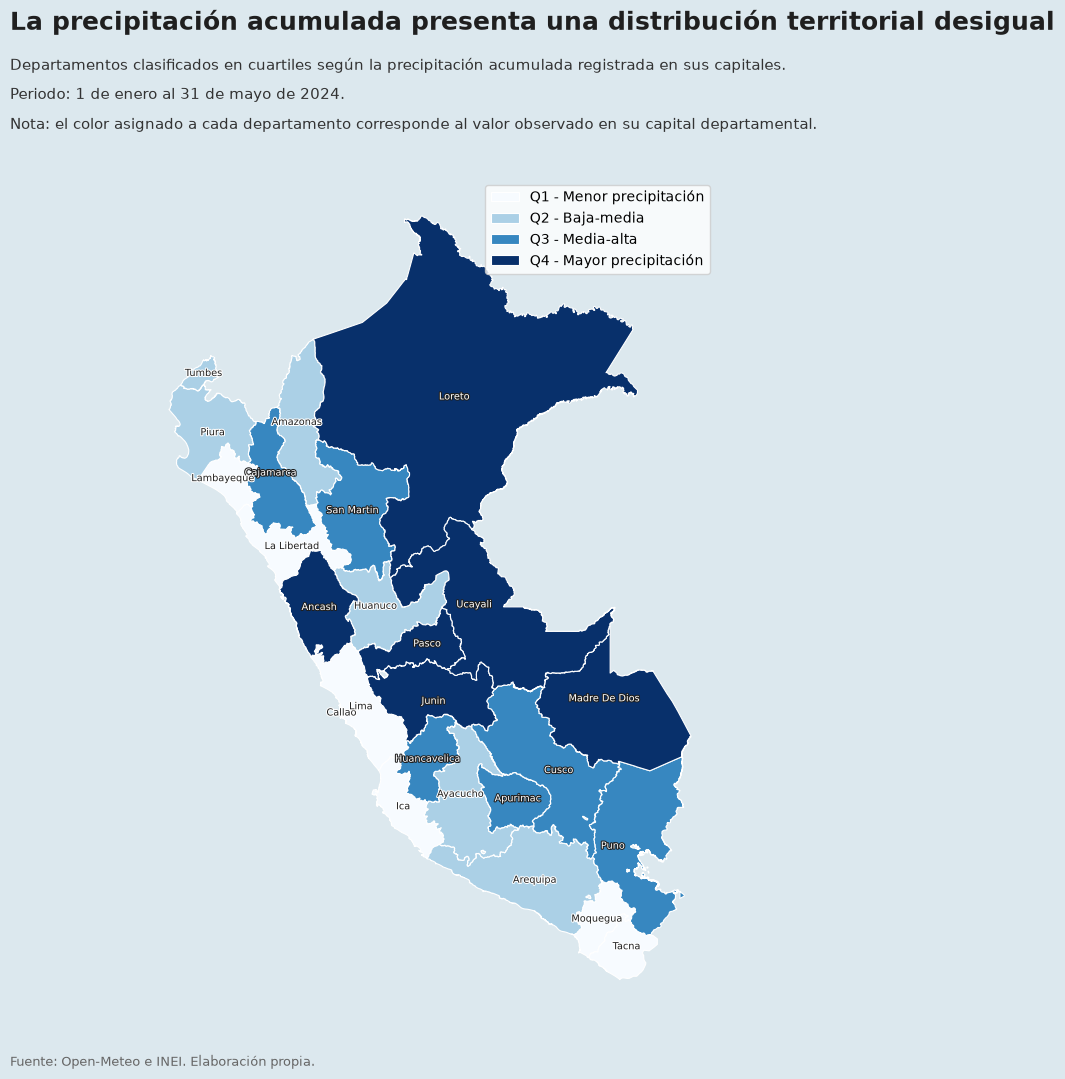

In [122]:
# Importa efectos para poner borde al texto.
import matplotlib.patheffects as pe

# Crea la figura y el eje donde se dibujará la coropleta.
fig, ax = plt.subplots(figsize=(10, 12))


# Define un fondo claro para mantener el estilo visual del trabajo.
fondo = "#DCE8EE"

# Aplica el color de fondo a toda la figura.
fig.patch.set_facecolor(fondo)

# Aplica el mismo color de fondo al área del mapa.
ax.set_facecolor(fondo)


# Dibuja los departamentos coloreados según el cuartil de precipitación.
# cmap="Blues" usa una escala secuencial de claro a oscuro.
mapa_cuantiles.plot(
    column="cuartil_lluvia",
    categorical=True,
    cmap="Blues",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)

# Recorre cada departamento del mapa para agregar su nombre.
for indice, fila in mapa_cuantiles.iterrows():

    # Calcula un punto representativo dentro del polígono.
    punto = fila.geometry.representative_point()

    # Define el color del texto según el cuartil.
    if fila["cuartil_lluvia"] in ["Q3 - Media-alta", "Q4 - Mayor precipitación"]:
        color_texto = "#FFFFFF"   # blanco para fondos oscuros
        color_borde = "#1F1F1F"   # borde oscuro
    else:
        color_texto = "#1F1F1F"   # gris oscuro para fondos claros
        color_borde = "#FFFFFF"   # borde blanco

    # Escribe el nombre del departamento sobre el mapa.
    ax.text(
        punto.x,
        punto.y,
        fila["NOMBDEP"].title(),
        fontsize=7,
        ha="center",
        va="center",
        color=color_texto,
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground=color_borde)
        ]
    )

# Elimina los ejes porque no aportan información útil en este mapa.
ax.set_axis_off()


# Agrega el título principal.
fig.text(
    0.08,
    0.94,
    "La precipitación acumulada presenta una distribución territorial desigual",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top",
    color="#1F1F1F"
)


# Agrega el subtítulo.
fig.text(
    0.08,
    0.90,
    "Departamentos clasificados en cuartiles según la precipitación acumulada registrada en sus capitales.",
    fontsize=11,
    ha="left",
    va="top",
    color="#333333"
)


# Agrega el periodo analizado.
fig.text(
    0.08,
    0.875,
    "Periodo: 1 de enero al 31 de mayo de 2024.",
    fontsize=10.5,
    ha="left",
    va="top",
    color="#333333"
)


# Agrega una nota metodológica.
fig.text(
    0.08,
    0.85,
    "Nota: el color asignado a cada departamento corresponde al valor observado en su capital departamental.",
    fontsize=10.5,
    ha="left",
    va="top",
    color="#333333"
)


# Agrega la fuente.
fig.text(
    0.08,
    0.06,
    "Fuente: Open-Meteo e INEI. Elaboración propia.",
    fontsize=9.5,
    ha="left",
    color="#666666"
)


# Ajusta los márgenes para que el mapa no se superponga
# con el título, subtítulo o fuente.
plt.subplots_adjust(
    top=0.80,
    bottom=0.10,
    left=0.03,
    right=0.97
)


# Muestra el mapa.
plt.show()

## ¿Cómo se distribuyen geográficamente los departamentos según su posición relativa en la distribución de precipitación acumulada?

Interpretación. La distribución espacial muestra una concentración de los valores relativos más altos de precipitación acumulada en parte del oriente y del centro del país. Loreto, Ucayali y Madre de Dios se ubican en el cuartil superior, junto con departamentos como Junín, Áncash y Pasco. En contraste, varios departamentos de la costa presentan valores correspondientes a los cuartiles inferiores, particularmente Lima, Ica, La Libertad, Lambayeque, Moquegua y Tacna. El mapa sugiere, por tanto, un patrón espacial en el que los mayores acumulados se concentran principalmente hacia el centro y oriente del territorio analizado, mientras que los menores valores predominan en buena parte de la costa.

Limitación. Aunque la coropleta colorea toda la superficie de cada departamento, el valor de precipitación utilizado proviene únicamente del punto meteorológico asociado a su capital. Por ello, el mapa no representa la precipitación promedio ni la distribución interna de la lluvia dentro de cada departamento. Esta limitación es especialmente importante en territorios extensos y con alta heterogeneidad geográfica y climática. La coropleta debe interpretarse, por tanto, como una representación de la posición relativa del valor observado en cada capital y no como una caracterización climática de todo el territorio departamental.

Fuentes de los datos de límites departamentales:

Geo GPS Perú:

https://www.geogpsperu.com/2020/04/limite-departamental-politico-shapefile.html?utm_source=chatgpt.com

https://drive.google.com/file/d/1x6Kl7FRQaJC26Rj97ar5hsw2nr360xdJ/view